使用纯Model的方法控制标记点的运动为直线

上游代码 -> `ControlLineMPC-Qualisys.py`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [70]:
num:int = 1
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
j_calc_np = np.loadtxt(f'j_measure_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = ur_data['timestamp'].to_numpy()
time -= time[0]

rob_pose_x = ur_data['actual_TCP_pose_0'].to_numpy()
rob_pose_y = ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


In [72]:
def plot_loss(loss_np):
    step_num = loss_np.shape[0]
    plot_step_num = 50

    # plot loss curve
    fig = plt.figure(figsize=(9, 3), dpi=100)
    gs = GridSpec(1, 1, figure=fig)

    # 获取 tab20 颜色映射
    colors = plt.cm.tab20.colors
    # 定义远离红色的颜色（排除红色及其相近颜色）
    filtered_colors = [color for color in colors if not (
        color[0] > 0.8 and color[1] < 0.2 and color[2] < 0.2)]

    axs_loss = fig.add_subplot(gs[0, :])
    axs_loss.patch.set_visible(False)
    axs_loss2 = axs_loss.twinx()
    axs_loss2.set_zorder(axs_loss.get_zorder() - 1)
    axs_loss.plot(loss_np[:plot_step_num, 0], marker='.', linestyle='-', color=filtered_colors[0 % len(colors)], label=f'Distance Loss', zorder=3)
    axs_loss2.plot(loss_np[:plot_step_num, 1], marker='.', linestyle='-', color=filtered_colors[1 % len(colors)], label=f'Perpendicular Loss', zorder=1)
    # axs_loss.plot(np.sum(loss_np[:plot_step_num], axis=1), marker='.', linestyle='-', color='r', label='Loss Sum')
    axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
    axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
    axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
    axs_loss.set_xlim([-1, plot_step_num])
    axs_loss.xaxis.set_major_locator(MultipleLocator(10))
    axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
    axs_loss.grid(True, zorder=1)

In [80]:
def plot_traj(rob_pose_x, rob_pose_y, dot_soft_np):
    fig = plt.figure(figsize=(8, 4), dpi=100)
    gs = GridSpec(1, 2, figure=fig)

    indices = np.linspace(0, len(rob_pose_x)-1, step_num, dtype=int)
    rows = np.arange(step_num)
    norm = plt.Normalize(rows.min(), rows.max())
    colors = plt.cm.plasma(norm(rows))

    axs_rob_mov = fig.add_subplot(gs[0, 0])
    rob_pose_xy = np.stack([rob_pose_x[indices][:50], rob_pose_y[indices][:50]], axis=1).reshape(-1, 1, 2)
    segments = np.concatenate([rob_pose_xy[:-1], rob_pose_xy[1:]], axis=1)
    lc = LineCollection(segments * 1000, colors=colors, norm=norm)
    axs_rob_mov.add_collection(lc)
    axs_rob_mov.autoscale()
    axs_rob_mov.set_title('Robot Tool Movement', fontsize=14, fontname='Times New Roman')
    # axs_rob_mov.set_xlabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
    # axs_rob_mov.set_ylabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
    axs_rob_mov.set_aspect('equal', 'datalim')
    axs_rob_mov.grid(True)

    axs_dot_mov = fig.add_subplot(gs[0, 1])
    init_pos = np.array([dot_soft_np[0, 1]*1000, dot_soft_np[0, 0]*1000])
    desired_pos = np.array([init_pos[0] - 0.008*1000, init_pos[1] + 0.006*1000])
    # desired_pos = np.array([init_pos[0], init_pos[1] + 0.01*1000])
    dots_soft = np.stack([dot_soft_np[:50, 1], dot_soft_np[:50, 0]], axis=1).reshape(-1, 1, 2)
    segments = np.concatenate([dots_soft[:-1], dots_soft[1:]], axis=1)
    lc = LineCollection(segments * 1000., colors=colors, norm=norm)
    axs_dot_mov.add_collection(lc)
    axs_dot_mov.autoscale()
    axs_dot_mov.scatter(init_pos[0], init_pos[1], c='blue', s=10, zorder=3)
    axs_dot_mov.scatter(desired_pos[0], desired_pos[1], c='red', s=10, zorder=3)
    axs_dot_mov.plot([init_pos[0], desired_pos[0]], [init_pos[1], desired_pos[1]], color='seagreen', linestyle='--', zorder=1)
    axs_dot_mov.set_title(f'Marker Movement', fontsize=14, fontname='Times New Roman')
    axs_dot_mov.set_aspect('equal', 'datalim')
    axs_dot_mov.grid(True, zorder=0)

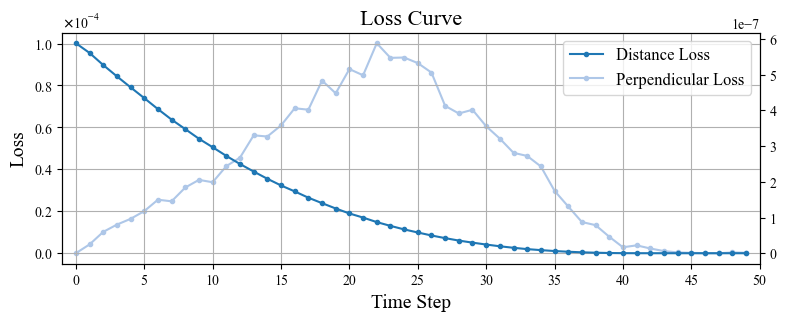

In [74]:
plot_loss(loss_np)

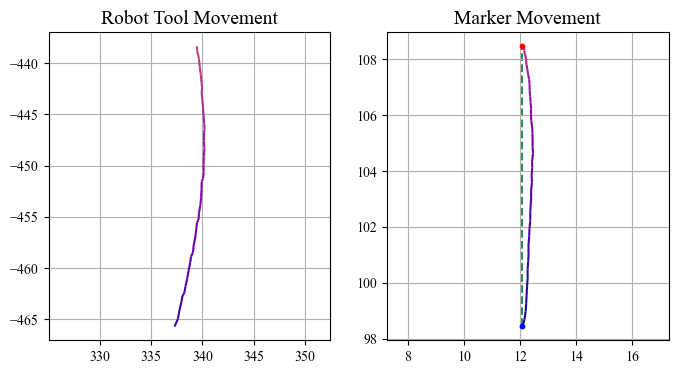

In [71]:
plot_traj(rob_pose_x, rob_pose_y, dot_soft_np)

In [75]:
num:int = 2
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
j_calc_np = np.loadtxt(f'j_measure_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

time = ur_data['timestamp'].to_numpy()
time -= time[0]

rob_pose_x = ur_data['actual_TCP_pose_0'].to_numpy()
rob_pose_y = ur_data['actual_TCP_pose_1'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


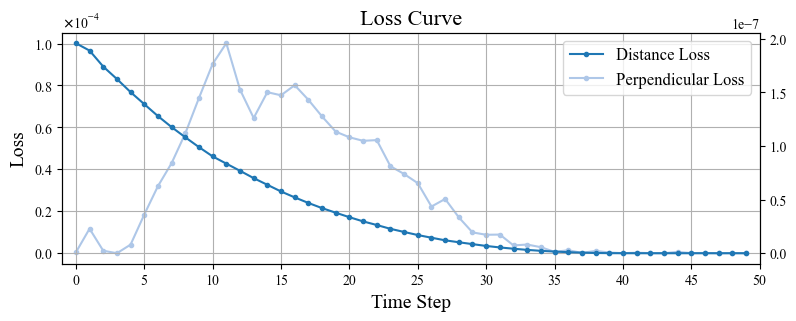

In [76]:
plot_loss(loss_np)

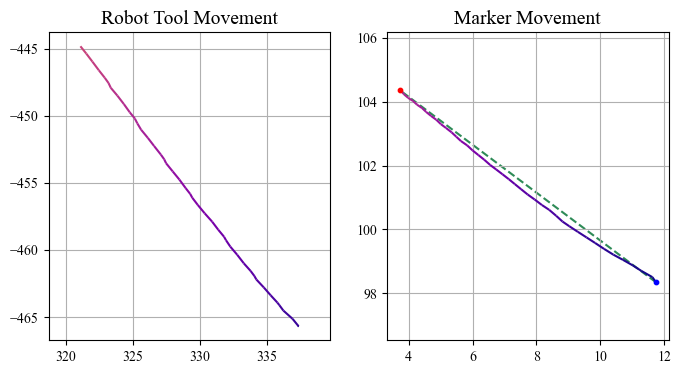

In [81]:
plot_traj(rob_pose_x, rob_pose_y, dot_soft_np)